In [ ]:
BUISNESS CASE- client
PROBLEM STATEMENT- classification

DATA SCIENCE

# Loan Repayment Prediction:

In [15]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as  plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
DATA VALIDATION - columns, missivg column

# 1.Data Gathering

In [16]:
#Load the Data & statistical analysis
def load_data():
    train=pd.read_csv('C:\\Users\\91976\\Desktop\\Velocity project\\Finance-LoanPrediction\\loan.csv')
    print(train.shape)
    print(train.info())
    print(train.describe().T)
    
    #Categorical Features
    cat_features=train.select_dtypes(include='object').columns
    print("Categorical Features:\n",cat_features,"\n No of categorical features:",len(cat_features))
    
    #Numerical Features
    num_features=train.select_dtypes(exclude='object').columns
    print("Numerical Features:\n",num_features,"\n No of numerical features:",len(num_features))
    return train

# 2. Exploratory Data Anaysis


In [17]:
def exploratory_analysis(train):
    #Create copy of dataframe 
    df=train.copy()
    df.dropna(inplace=True)
    
    #Count of target Feature
    print(train['bad_loan'].value_counts())
    plt.figure(figsize=(5,5))
    plt.title("Count of bad_loan")
    sns.countplot(train['bad_loan'],palette='plasma')
    plt.xticks(ticks=np.arange(2),labels=['Good Customer','Bad Customer'])
    plt.show()
    
    plt.figure(figsize=(5,5))
    train['bad_loan'].value_counts().plot(kind='pie',labels=['Good Customers','Bad Customers'],autopct="%1.2f%%")
    plt.show()
    #Conclusion: Dataset is imbalanced as bad_customers are less than good customers
    
    #Count of target Feature
    print(train['bad_loan'].value_counts())
    plt.figure(figsize=(5,5))
    plt.title("Count of bad_loan")
    sns.countplot(train['bad_loan'],palette='plasma')
    plt.xticks(ticks=np.arange(2),labels=['Good Customer','Bad Customer'])
    plt.show()
    plt.figure(figsize=(5,5))
    train['bad_loan'].value_counts().plot(kind='pie',labels=['Good Customers','Bad Customers'],autopct="%1.2f%%")
    plt.show()
    #Conclusion: Dataset is imbalanced as bad_customers are less than good customers
    
    #Distribution of loan amount
    plt.figure(figsize=(5,5))
    plt.title("Histogram for Loan Amount ")
    plt.hist(df['loan_amnt'])
    plt.xlabel("Loan Amount")
    plt.ylabel("Count")
    plt.show()
    
    plt.figure(figsize=(5,5))
    sns.distplot(df['loan_amnt'])
    #Conclusion:Major customers took loan in range of(5000-10000), few customers took loan with amoun as 30000-35000
    
    #Countplot of term 
    print(train['term'].value_counts())
    plt.figure(figsize=(8,5))
    plt.title("Countplot for term")
    sns.countplot(train['term'],palette='plasma')
    plt.xticks(ticks=np.arange(2),labels=['36 Months','60 Months'])
    plt.show()
    
    plt.figure(figsize=(5,5))
    train['term'].value_counts().plot(kind='pie',labels=['36 Months','60 Months'],autopct="%1.2f%%")
    plt.show()
    #Conclusion: Majority of loans are of 36 Month duration
    
    #Countplot for emp_length Feature
    print("EmpLength\tNo of customers")
    print(train['emp_length'].value_counts())

    plt.figure(figsize=(5,5))
    plt.title("Countplot for Employee Length")
    sns.countplot(train['emp_length'],palette='plasma')
    plt.xticks(ticks=np.arange(11))
    plt.show()
    #Conclusion: Majority of customers having employee length as 10
    
    #Relationship between Loan Amount and Annual Income
    plt.figure(figsize=(5,5))
    plt.scatter(df['loan_amnt'],np.log(df['annual_inc']))
    plt.title("Annual Income vs Loan Amount")
    plt.ylabel("Loan Amount")
    plt.xlabel("Annual Income")

    #Distribution of Annual Income
    plt.figure(figsize=(5,5))
    plt.title("Distribution Annual Income")
    plt.hist(df['annual_inc'],bins=20)
    plt.xticks(rotation=45)
    plt.xlabel("Annual Income")
    plt.ylabel("Count")
    plt.show()

    plt.figure(figsize=(5,5))
    sns.distplot(df['annual_inc'],bins=20)

    #As distribution is skewed apply log transformation on it
    #Distribution of Annual Income
    plt.figure(figsize=(5,5))
    plt.title("Distribution Annual Income")
    plt.hist(np.log(df['annual_inc']),bins=20)
    plt.xticks(rotation=45)
    plt.xlabel("Annual Income")
    plt.ylabel("Count")
    plt.show()

    plt.figure(figsize=(5,5))
    sns.distplot(np.log(df['annual_inc']),bins=20)
    #Conclusion:Major customers took loan in range of(5000-10000), few customers took loan with amoun as 30000-35000

    #Count of loan purpose
    print(train['purpose'].value_counts())

    plt.figure(figsize=(15,5))
    plt.title("Countplot for Loan Purpose")
    sns.countplot(train['purpose'],palette='plasma')
    plt.xlabel("Loan Purpose")
    plt.xticks(rotation=45)
    plt.show()
    #Conclusion: Majority of customers take loan for debit consolidation followed for credit card
    
    #Statewise customer count
    print(train['addr_state'].value_counts())
    plt.figure(figsize=(15,5))
    plt.title("Statewise Customer Count")
    sns.countplot(train['addr_state'],palette='plasma')
    plt.xlabel("State")
    plt.ylabel("Customer Count")
    plt.xticks(rotation=45)
    plt.show()
    #Conclusion:  state CA has majority  of customers , most of the states have average no of customers
    
    #Distribution of Debit to Income Ratio
    plt.figure(figsize=(5,5))
    plt.title("Distribution Debit-Income")
    sns.distplot(df['dti'])
    plt.xlabel("Debit-Income Ratio")
    plt.ylabel("Count")
    plt.show()

    #Distribution of Revol_util
    plt.figure(figsize=(5,5))
    plt.title("Distribution Revol_Util")
    sns.distplot(df['revol_util'])
    plt.xlabel("Revol_Util")
    plt.ylabel("Count")
    plt.show()
    
    #Distribution of total account 
    plt.figure(figsize=(5,5))
    plt.title("Histogram for total account")
    plt.hist(df['total_acc'])
    plt.xlabel("Total Account")
    plt.ylabel("Count")
    plt.show()  
    
    #Count of Longest Credit length
    plt.figure(figsize=(5,5))
    plt.title("Countplot for Longest Credit Length")
    sns.distplot(df['longest_credit_length'])
    plt.show()

    #Count of House Ownership
    print(train['home_ownership'].value_counts())

    plt.figure(figsize=(5,5))
    plt.title("Countplot of House Ownership")
    sns.countplot(train['home_ownership'])
    plt.xticks(ticks=np.arange(6),labels=['MORTGAGE','RENT','OWN','OTHER','NONE','ANY'])
    plt.show()

    plt.figure(figsize=(7,5))
    train['home_ownership'].value_counts().plot(kind='pie',labels=['MORTGAGE','RENT','OWN','OTHER','NONE','ANY'],autopct="%1.2f%%")
    plt.show()    
  
    #Count of Verified and Not verified Customers
    print(train['verification_status'].value_counts())

    plt.figure(figsize=(5,5))
    plt.title("Countplot by Verification Status")
    sns.countplot(train['verification_status'],palette='plasma')
    plt.xticks(ticks=np.arange(2),labels=['Verified','Not Verified'])
    plt.show()

    plt.figure(figsize=(5,5))
    train['verification_status'].value_counts().plot(kind='pie',labels=['Verified','Not Verified'],autopct="%1.2f%%")
    plt.show()

    #Correlation of features
    plt.figure(figsize=(10,10))
    sns.heatmap(df.corr(),annot=True,cbar=True,cmap='viridis',linewidth=0.2)
    plt.yticks(rotation=0)   
    
   #Checking for outlier
    plt.figure(figsize=(5,5))
    sns.boxplot(y=np.log(df['annual_inc']))
    #There exist extrem value for annual income 
    
    

# 3.Feature Engineering

In [18]:
def feature_engg(train):
    #Filling Missing Values
    print(train.isnull().sum())
    #Employee Length:Fill na values with mean
    train['emp_length'].fillna(train['emp_length'].mean(skipna=True),inplace=True)
    
    #Annual Income:mean income
    train['annual_inc'].fillna(train['annual_inc'].median(),inplace=True)
    
    #delinq_2 yrs
    train['delinq_2yrs'].fillna(train['delinq_2yrs'].mean(skipna=True),inplace=True)
    
    #revol_util
    train['revol_util'].fillna(train['revol_util'].median(),inplace=True)
    
    #revol_util
    train['total_acc'].fillna(train['total_acc'].median(),inplace=True)
    
    #longest_credit_length
    train['longest_credit_length'].fillna(train['longest_credit_length'].median(),inplace=True)
    print(train.isnull().sum())
    
    #Categorical Features
    cat_features=train.select_dtypes(include='object').columns
    print("Categorical Features:\n",cat_features,"\n No of categorical features:",len(cat_features))
    #Converting Categorical-Numeric features using Label Encoding
    le=LabelEncoder()
    for feature in cat_features:
        train[feature]=le.fit_transform(train[feature])
    
    #Apply log transformation to deal with skewness of annual income
    train['annual_inc']=np.log(train['annual_inc'])
    return train

(163987, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163987 entries, 0 to 163986
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   loan_amnt              163987 non-null  int64  
 1   term                   163987 non-null  object 
 2   int_rate               163987 non-null  float64
 3   emp_length             158183 non-null  float64
 4   home_ownership         163987 non-null  object 
 5   annual_inc             163983 non-null  float64
 6   purpose                163987 non-null  object 
 7   addr_state             163987 non-null  object 
 8   dti                    163987 non-null  float64
 9   delinq_2yrs            163958 non-null  float64
 10  revol_util             163794 non-null  float64
 11  total_acc              163958 non-null  float64
 12  bad_loan               163987 non-null  int64  
 13  longest_credit_length  163958 non-null  float64
 14  verification_status    

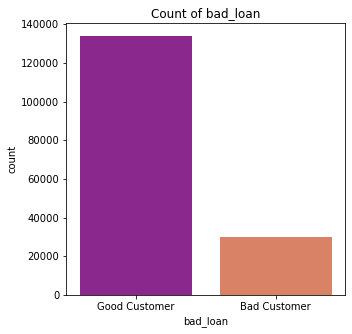

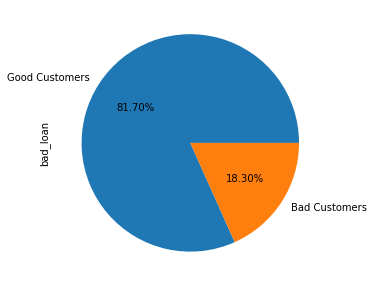

0    133971
1     30016
Name: bad_loan, dtype: int64


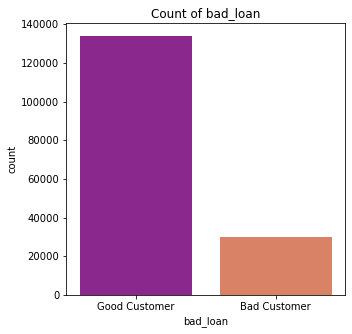

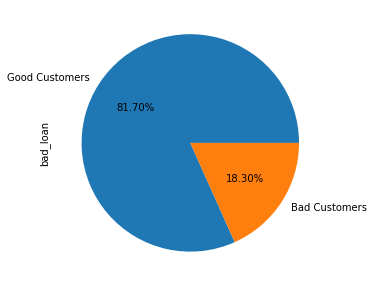

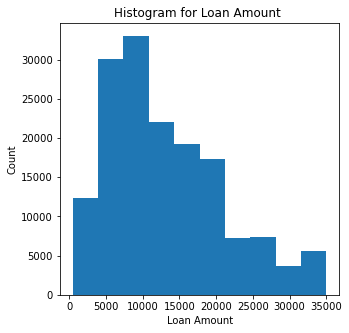

36 months    129950
60 months     34037
Name: term, dtype: int64


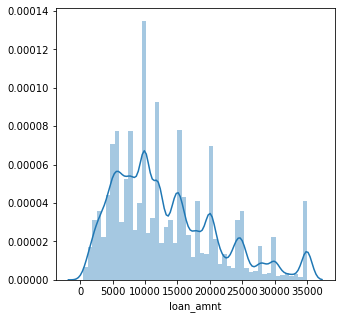

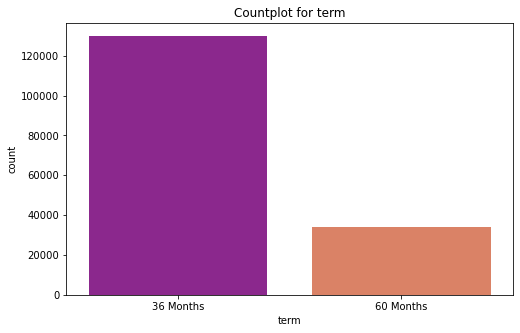

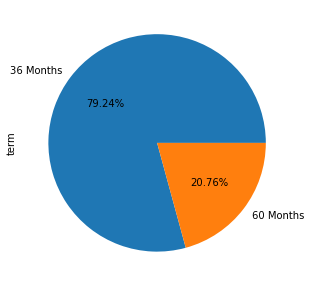

EmpLength	No of customers
10.0    47183
2.0     15766
0.0     14248
3.0     13611
5.0     12347
1.0     11414
4.0     11024
6.0     10000
7.0      9079
8.0      7424
9.0      6087
Name: emp_length, dtype: int64


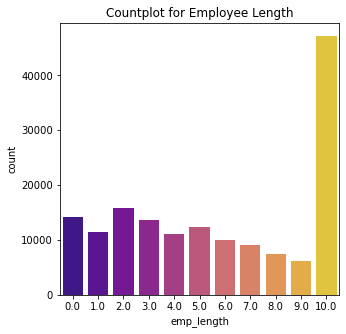

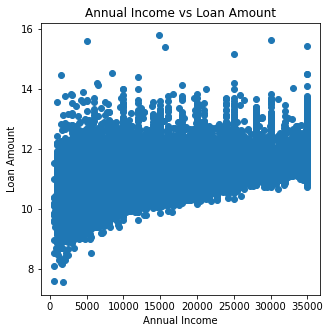

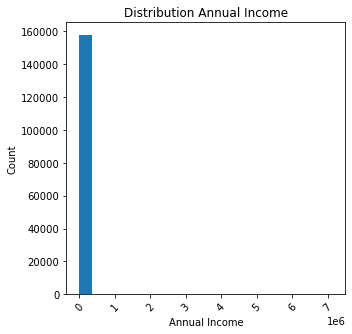

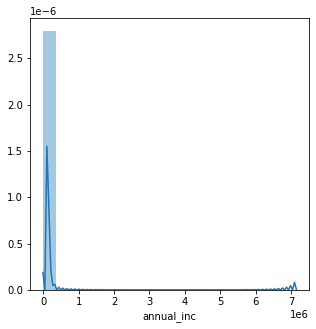

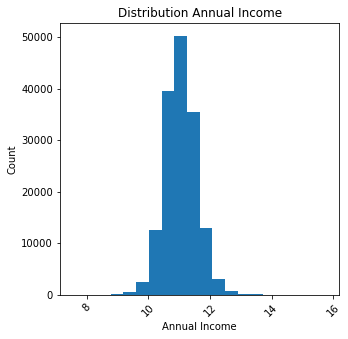

debt_consolidation    93261
credit_card           30792
other                 10492
home_improvement       9872
major_purchase         4686
small_business         3841
car                    2842
medical                2029
wedding                1751
moving                 1464
house                  1245
vacation               1096
educational             418
renewable_energy        198
Name: purpose, dtype: int64


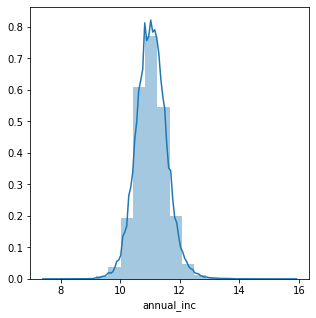

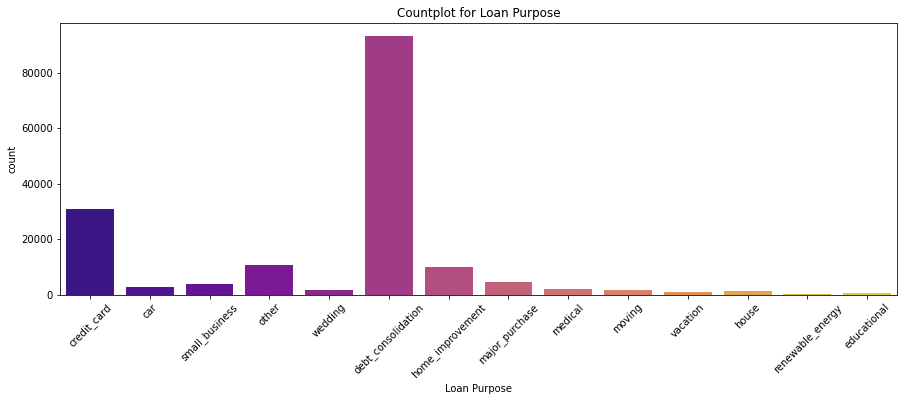

CA    28702
NY    14285
TX    12128
FL    11396
NJ     6457
IL     6099
PA     5427
VA     5282
GA     5189
OH     4896
NC     4393
MA     4164
AZ     3941
MD     3890
WA     3823
MI     3762
CO     3531
MN     2771
MO     2627
CT     2563
NV     2387
OR     2149
WI     1980
AL     1965
LA     1885
SC     1826
KY     1477
IN     1463
UT     1389
KS     1335
OK     1331
TN     1327
AR     1104
HI      955
NM      839
NH      752
WV      714
RI      695
DC      584
MT      483
DE      445
AK      413
WY      376
SD      317
VT      270
MS      163
NE       13
IA       12
ID        9
ME        3
Name: addr_state, dtype: int64


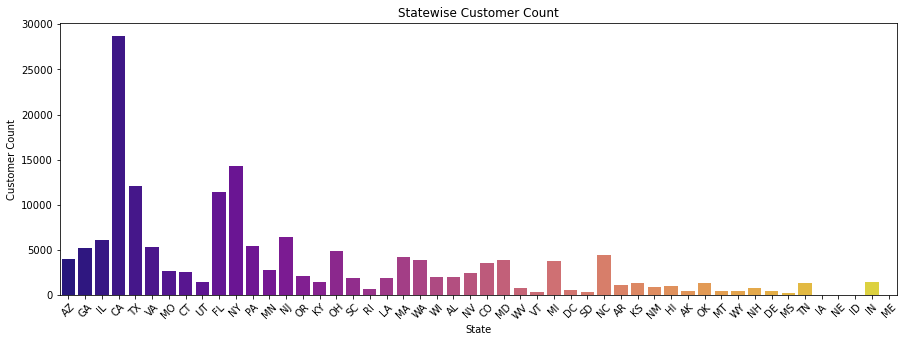

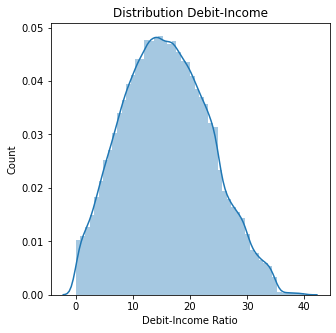

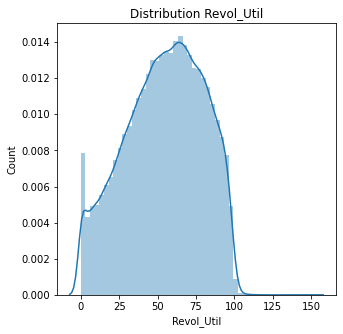

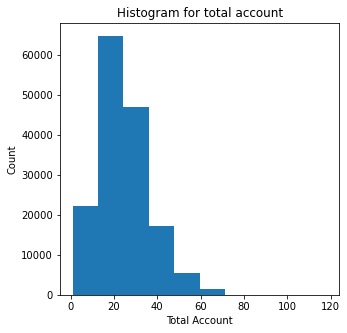

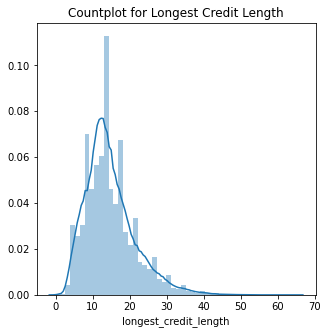

MORTGAGE    79714
RENT        70526
OWN         13560
OTHER         156
NONE           30
ANY             1
Name: home_ownership, dtype: int64


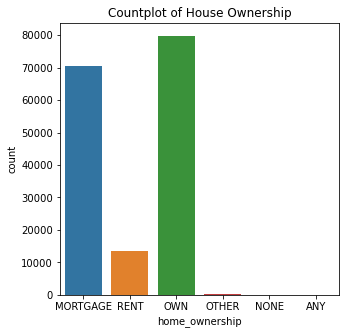

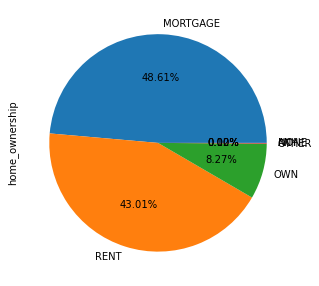

verified        104832
not verified     59155
Name: verification_status, dtype: int64


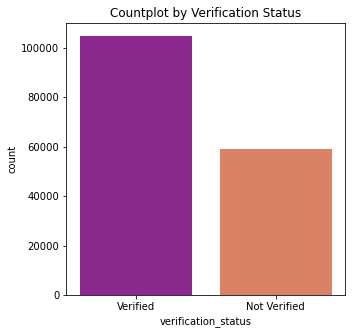

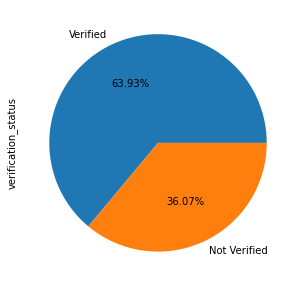

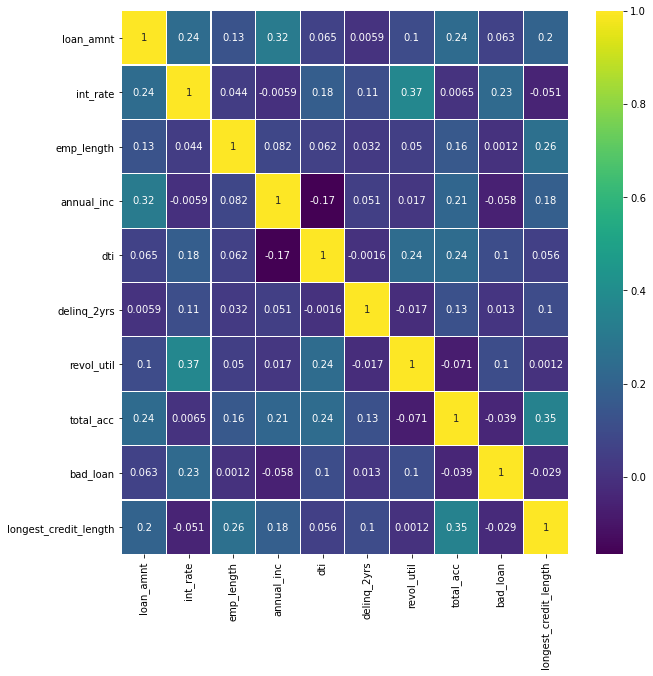

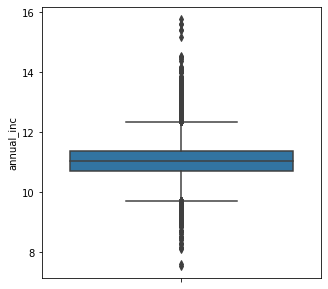

In [19]:
#Function call
train=load_data()
exploratory_analysis(train)


In [6]:
train=feature_engg(train)
print(train.head(5))

loan_amnt                   0
term                        0
int_rate                    0
emp_length               5804
home_ownership              0
annual_inc                  4
purpose                     0
addr_state                  0
dti                         0
delinq_2yrs                29
revol_util                193
total_acc                  29
bad_loan                    0
longest_credit_length      29
verification_status         0
dtype: int64
loan_amnt                0
term                     0
int_rate                 0
emp_length               0
home_ownership           0
annual_inc               0
purpose                  0
addr_state               0
dti                      0
delinq_2yrs              0
revol_util               0
total_acc                0
bad_loan                 0
longest_credit_length    0
verification_status      0
dtype: int64
Categorical Features:
 Index(['term', 'home_ownership', 'purpose', 'addr_state',
       'verification_status'],
      d

In [ ]:
PCA/
FEATURE SELECTION- Techniues


# 4. Classification Model

# Logistic Regression

In [20]:
# Split into train and test data
x=train.drop('bad_loan',axis=1)
y=train.bad_loan
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

#Feature Scaling
rs=RobustScaler()
x_train=rs.fit_transform(x_train)
x_test=rs.transform(x_test)

(131189, 14) (131189,) (32798, 14) (32798,)


ValueError: could not convert string to float: '36 months'

In [8]:
#Without CV & without Feature Selection
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(solver='liblinear')
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))


Accuracy: 0.8160253674004513
Confusion Matrix:
 [[26555   274]
 [ 5760   209]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.99      0.90     26829
           1       0.43      0.04      0.06      5969

    accuracy                           0.82     32798
   macro avg       0.63      0.51      0.48     32798
weighted avg       0.75      0.82      0.75     32798



In [9]:
#With CV & without Feature Selection
#Cross Validation
sc=RobustScaler()
x=sc.fit_transform(x)
cv_score=cross_val_score(model,x,y,cv=10)
print("Accuracy with Cross Validation:",np.mean(cv_score))

Accuracy with Cross Validation: 0.816369572613896


# Feature Selection:Pearson's Correlation Coefficient

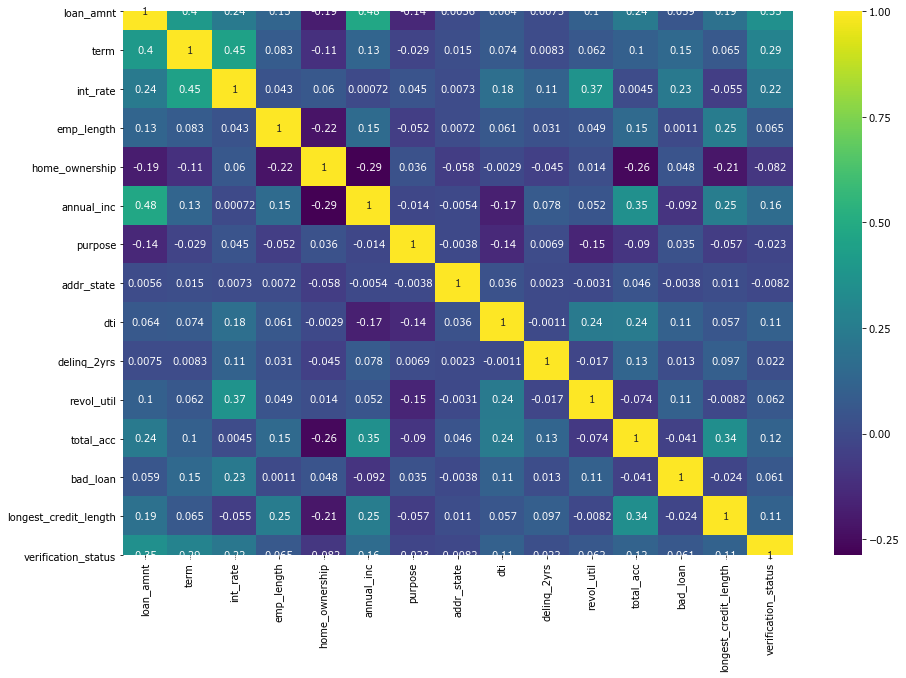

In [10]:
#Feature Selection : Correlation matrix
plt.figure(figsize=(15,10))
sns.heatmap(train.corr(),annot=True,cmap='viridis')

In [11]:
#Feature Selection using correlation coefficient
correlated_features = set()
irrelevant_features=set()
correlation_matrix = train.corr()
'''
#Checking entire correlation matrix
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            colname = correlation_matrix.columns[i]
            correlated_features.add(colname)
        if abs(correlation_matrix.iloc[i, j]) < 0.05:
            colname = correlation_matrix.columns[i]
            irrelevant_features.add(colname)
'''
#Checking Correlation of all features with respect to target feature
i=12   #index of target feature
for j in range(0,15):
    if abs(correlation_matrix.iloc[i, j]) > 0.8:
        colname = correlation_matrix.columns[j]
        correlated_features.add(colname)
    if abs(correlation_matrix.iloc[i, j]) < 0.05:
        colname1 = correlation_matrix.columns[j]
        irrelevant_features.add(colname1)            
print("Correlated features are as: {} ,Total No of Correlated features:{}".format(correlated_features,len(correlated_features)))
print("Irrelevant features are as: {} ,Total No of Irrelevant features:{}".format(irrelevant_features,len(irrelevant_features)))

#Creates a copy of dataset
df=train.copy()
#Dropping irrelevant features
df.drop(irrelevant_features,axis=1,inplace=True)
print(df.shape)

Correlated features are as: {'bad_loan'} ,Total No of Correlated features:1
Irrelevant features are as: {'total_acc', 'delinq_2yrs', 'longest_credit_length', 'purpose', 'addr_state', 'emp_length', 'home_ownership'} ,Total No of Irrelevant features:7
(163987, 8)


In [12]:
#Splitting of dataset - train,test data after dropping irrelevant features
x1=df.drop('bad_loan',axis=1)
y1=df.bad_loan
x_train1,x_test1,y_train1,y_test1=train_test_split(x1,y1,test_size=0.2,random_state=0)
print(x_train1.shape,y_train1.shape,x_test1.shape,y_test1.shape)

#Feature Scaling
rs=RobustScaler()
x_train1=rs.fit_transform(x_train1)
x_test1=rs.transform(x_test1)

(131189, 7) (131189,) (32798, 7) (32798,)


In [13]:
#Building model : Logistic Regression
#Without CV & with Feature Selection
model.fit(x_train1,y_train1)
y_pred=model.predict(x_test1)
print("Accuracy:",accuracy_score(y_test1,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test1,y_pred))
print("Confusion Matrix:\n",classification_report(y_test1,y_pred))

Accuracy: 0.8160558570644552
Confusion Matrix:
 [[26586   243]
 [ 5790   179]]
Confusion Matrix:
               precision    recall  f1-score   support

           0       0.82      0.99      0.90     26829
           1       0.42      0.03      0.06      5969

    accuracy                           0.82     32798
   macro avg       0.62      0.51      0.48     32798
weighted avg       0.75      0.82      0.74     32798



In [14]:
#Cross Validation
#With CV & With Feature Selection
x1=sc.fit_transform(x1)
cv_score=cross_val_score(model,x1,y1,cv=10)
print("Accuracy with Cross Validation:",np.mean(cv_score))

Accuracy with Cross Validation: 0.8162963829173364


# Decision Tree

In [15]:
#Without CV & without Feature Selection
from sklearn import tree
dtree = tree.DecisionTreeClassifier(random_state=17)
dtree.fit(x_train,y_train)
y_pred=dtree.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7157448624916154
[[21845  4984]
 [ 4339  1630]]
              precision    recall  f1-score   support

           0       0.83      0.81      0.82     26829
           1       0.25      0.27      0.26      5969

    accuracy                           0.72     32798
   macro avg       0.54      0.54      0.54     32798
weighted avg       0.73      0.72      0.72     32798



In [16]:
#Without CV & with Feature Selection
cv_score=cross_val_score(dtree,x,y,cv=10)
print("Accuracy:",np.mean(cv_score))

Accuracy: 0.7106051325524662


In [17]:
#Without CV & with Feature Selection
dtree.fit(x_train1,y_train1)
y_pred=dtree.predict(x_test1)
print(accuracy_score(y_test1,y_pred))
print(confusion_matrix(y_test1,y_pred))
print(classification_report(y_test1,y_pred))

0.7138849929873773
[[21804  5025]
 [ 4359  1610]]
              precision    recall  f1-score   support

           0       0.83      0.81      0.82     26829
           1       0.24      0.27      0.26      5969

    accuracy                           0.71     32798
   macro avg       0.54      0.54      0.54     32798
weighted avg       0.73      0.71      0.72     32798



In [18]:
#With CV & with Feature Selection
cv_score=cross_val_score(dtree,x1,y1,cv=10)
print("Accuracy:",np.mean(cv_score))

Accuracy: 0.7077391428106334


# ADABoost

In [19]:
#Without CV & without Feature Selection
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
adb=AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),n_estimators=100)
adb.fit(x_train,y_train)
y_pred=adb.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Confusion Matrix:\n",classification_report(y_test,y_pred))

Accuracy: 0.81703152631258
Confusion Matrix:
 [[26615   214]
 [ 5787   182]]
Confusion Matrix:
               precision    recall  f1-score   support

           0       0.82      0.99      0.90     26829
           1       0.46      0.03      0.06      5969

    accuracy                           0.82     32798
   macro avg       0.64      0.51      0.48     32798
weighted avg       0.76      0.82      0.75     32798



In [20]:
#Without CV & without Feature Selection
adb=AdaBoostClassifier()
cv_score=cross_val_score(adb,x,y,cv=10)
print("Accuracy:",np.mean(cv_score))

Accuracy: 0.8164793614352464


In [21]:
#without CV &  with Feature selection
adb.fit(x_train1,y_train1)
y_pred=adb.predict(x_test1)
print("Accuracy:",accuracy_score(y_test1,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test1,y_pred))
print("Confusion Matrix:\n",classification_report(y_test1,y_pred))

Accuracy: 0.8178242575766815
Confusion Matrix:
 [[26694   135]
 [ 5840   129]]
Confusion Matrix:
               precision    recall  f1-score   support

           0       0.82      0.99      0.90     26829
           1       0.49      0.02      0.04      5969

    accuracy                           0.82     32798
   macro avg       0.65      0.51      0.47     32798
weighted avg       0.76      0.82      0.74     32798



In [22]:
#With CV & with Feature Selection
cv_score=cross_val_score(adb,x1,y1,cv=10)
print("Accuracy:",np.mean(cv_score))

Accuracy: 0.8167476593223653


# Random Forest

In [23]:
#Without CV & without Feature Selection
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)
y_pred= rfc.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Confusion Matrix:\n",classification_report(y_test,y_pred))

Accuracy: 0.8162997743764864
Confusion Matrix:
 [[26550   279]
 [ 5746   223]]
Confusion Matrix:
               precision    recall  f1-score   support

           0       0.82      0.99      0.90     26829
           1       0.44      0.04      0.07      5969

    accuracy                           0.82     32798
   macro avg       0.63      0.51      0.48     32798
weighted avg       0.75      0.82      0.75     32798



In [24]:
#Without CV & without Feature Selection
cv_score=cross_val_score(rfc,x,y,cv=10)
print("Accuracy:",np.mean(cv_score))

Accuracy: 0.8155463479670854


In [25]:
#Without CV & with Feature Selection
rfc.fit(x_train1, y_train1)
y_pred= rfc.predict(x_test1)
print("Accuracy:",accuracy_score(y_test1,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test1,y_pred))
print("Confusion Matrix:\n",classification_report(y_test1,y_pred))

Accuracy: 0.8129459113360571
Confusion Matrix:
 [[26305   524]
 [ 5611   358]]
Confusion Matrix:
               precision    recall  f1-score   support

           0       0.82      0.98      0.90     26829
           1       0.41      0.06      0.10      5969

    accuracy                           0.81     32798
   macro avg       0.62      0.52      0.50     32798
weighted avg       0.75      0.81      0.75     32798



In [26]:
#With CV & with Feature Selection
cv_score=cross_val_score(rfc,x1,y1,cv=10)
print("Accuracy:",np.mean(cv_score))

Accuracy: 0.8112533277856201


# 5. Refinement  of model :  Improving Accuracy of model


# 5.1. Removing all Categorical Features

In [27]:
from sklearn.preprocessing import MinMaxScaler
df=train.drop(cat_features,axis=1)
df.columns
#Apply log transformation to deal with skewness of annual income
df['annual_inc']=np.log(df['annual_inc'])
#train-test split
# Split into train and test data
x=df.drop('bad_loan',axis=1)
y=df.bad_loan
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

#Feature Scaling
rs=StandardScaler()
x_train=rs.fit_transform(x_train)
x_test=rs.transform(x_test)

NameError: name 'cat_features' is not defined

In [ ]:
#Without CV 
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(solver='liblinear')
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))


# 5.2 Using PCA

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=4)
pc_x=pca.fit_transform(x)

x_train,x_test,y_train,y_test=train_test_split(pc_x,y,test_size=0.3,random_state=0)

model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))

lr=LogisticRegression()
cv_score=cross_val_score(lr,pc_x,y,cv=15)
print(np.mean(cv_score))

# 5.3 MLP Classifier

In [ ]:
train

In [ ]:
from sklearn.neural_network import MLPClassifier

# Split into train and test data
x=train.drop('bad_loan',axis=1)
y=train.bad_loan
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

#Feature Scaling
rs=MinMaxScaler()
x_train=rs.fit_transform(x_train)
x_test=rs.transform(x_test)

#Initialize the Multi Layer Perceptron Classifier
#model=MLPClassifier(alpha=0.01, batch_size=256, epsilon=1e-08, hidden_layer_sizes=(300,), learning_rate='adaptive', max_iter=500)
model=MLPClassifier()
#Train the model
model.fit(x_train,y_train)

#Predict for the test set
y_pred=model.predict(x_test)

#Calculate the accuracy of our model
accuracy=accuracy_score(y_true=y_test, y_pred=y_pred)

#Print the accuracy
print("Accuracy: {:.2f}%".format(accuracy*100))

# SMOTE

In [ ]:
!pip install imblearn

In [ ]:
import scipy

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:

#Apply log transformation to deal with skewness of annual income
df1['annual_inc']=np.log(df1['annual_inc'])

x=df1.drop('bad_loan',axis=1)
y=df1.bad_loan

#train-test split
# Split into train and test data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

#Feature Scaling
rs=StandardScaler()
x_train=rs.fit_transform(x_train)
x_test=rs.transform(x_test)
sm=SMOTE(random_state=12,ratio=1.0)

# FLASK API

DEPLOYMENT- AWS